In [85]:
# import os for traversing csv files
import os

# import tqdm for visualizing how long some loop will take
from tqdm import tqdm

# import pandas and numpy for math and data processing
import pandas as pd
import numpy as np

# import matplotlib and seaborn for plotting and visualizations
from matplotlib import pyplot as plt
import seaborn

# import gradient-boosted decision tree library - XGBoost
import xgboost as xgb

# import loss functions
from sklearn.metrics import brier_score_loss, mean_absolute_error

# import spline interpolation
from scipy.interpolate import UnivariateSpline

# options to suppress irrelevant errors and comprehensive display for pandas
pd.options.mode.chained_assignment = None 
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [86]:
# Load the men's data and save as dataframes
M_regular_season_results = pd.read_csv("data/MRegularSeasonDetailedResults.csv")
M_tourney_results = pd.read_csv("data/MNCAATourneyDetailedResults.csv")
M_seeds = pd.read_csv("data/MNCAATourneySeeds.csv")
M_teams = pd.read_csv("data/MTeams.csv")
M_ranks = pd.read_csv("data/MMasseyOrdinals.csv")

In [87]:
M_before_sweet = M_regular_season_results.copy(deep = True)
M_after_sweet = pd.DataFrame()

# print(len(M_before_sweet))

years = list(range(2003, 2026))
years.remove(2020)

for year in years:
    first_two_rounds = M_tourney_results[M_tourney_results["Season"]== year][:-15]
    sweet_onwards = M_tourney_results[M_tourney_results["Season"]== year][-15:]
    print(year, len(sweet_onwards), len(first_two_rounds))
    M_before_sweet = pd.concat([M_before_sweet, first_two_rounds])
    M_after_sweet = pd.concat([M_after_sweet, sweet_onwards])

print(len(M_before_sweet))
print(len(M_after_sweet))

2003 15 49
2004 15 49
2005 15 49
2006 15 49
2007 15 49
2008 15 49
2009 15 49
2010 15 49
2011 15 52
2012 15 52
2013 15 52
2014 15 52
2015 15 52
2016 15 52
2017 15 52
2018 15 52
2019 15 52
2021 15 51
2022 15 52
2023 15 52
2024 15 52
2025 15 52
125648
330


In [88]:
# helper function to prepare data by normalizing statistics for overtime and duplicate each game from
# both teams' perspectives
def prepare_data(results_df):
    
    # remove WLoc from features - Location - Home (H), Away (A), Neutral (N)
    all_but_WLoc = ["Season", "DayNum", "LTeamID", "LScore", "WTeamID", "WScore", "NumOT",
            "LFGM", "LFGA", "LFGM3", "LFGA3", "LFTM", "LFTA", "LOR", "LDR", "LAst", "LTO", "LStl", "LBlk", "LPF",
            "WFGM", "WFGA", "WFGM3", "WFGA3", "WFTM", "WFTA", "WOR", "WDR", "WAst", "WTO", "WStl", "WBlk", "WPF"]
    
    results_df = results_df[all_but_WLoc]

    # creates a column for OT adjustment factor based on NumOT column
    ot_adjust = (40 + 5 * results_df["NumOT"]) / 40

    # specify stats which need to be adjusted
    cols_adjust = ["LScore", "WScore", 
               "LFGM", "LFGA", "LFGM3", "LFGA3", "LFTM", "LFTA", "LOR", "LDR", "LAst", "LTO", "LStl", "LBlk", "LPF",
               "WFGM", "WFGA", "WFGM3", "WFGA3", "WFTM", "WFTA", "WOR", "WDR", "WAst", "WTO", "WStl", "WBlk", "WPF"]

    # for each column that needs to be adjusted, adjust by corresponding adjustment factor
    for col in cols_adjust:
        results_df[col] = results_df[col] / ot_adjust

    # need to have a copy for each result for each team's persepctive (helpful during aggregation)
    # Use T1 and T2 for column standardization instead of W and L
    results_df_symmetric = results_df.copy()
    results_df.columns = [x.replace("W", "T1_").replace("L", "T2_") for x in list(results_df.columns)]
    results_df_symmetric.columns =  [x.replace("L", "T1_").replace("W", "T2_") for x in list(results_df_symmetric.columns)]

    # combine both perspective results
    combined = pd.concat([results_df, results_df_symmetric]).reset_index(drop = True)

    # add point differential for game
    combined["PointDiff"] = combined["T1_Score"] - combined["T2_Score"]

    # add indicator for win for game
    combined["win"] = (combined["PointDiff"] > 0) * 1

    return combined

M_before_sweet_data = prepare_data(M_before_sweet)

print("Men's Regular Season Detailed Results:")
print(M_before_sweet_data)

M_sweet_onwards_data = prepare_data(M_after_sweet)

print("Men's Tourney Detailed Results:")
print(M_sweet_onwards_data)

Men's Regular Season Detailed Results:
        Season  DayNum  T2_TeamID  T2_Score  T1_TeamID  T1_Score  NumOT  T2_FGM  T2_FGA  T2_FGM3  T2_FGA3  T2_FTM  T2_FTA  T2_OR  T2_DR  T2_Ast  T2_TO  T2_Stl  T2_Blk  T2_PF  T1_FGM  T1_FGA  T1_FGM3  T1_FGA3  T1_FTM  T1_FTA  T1_OR  T1_DR  T1_Ast  T1_TO  T1_Stl  T1_Blk  T1_PF  PointDiff  win
0         2003      10       1328      62.0       1104      68.0      0    22.0    53.0      2.0     10.0    16.0    22.0   10.0   22.0     8.0   18.0     9.0     2.0   20.0    27.0    58.0      3.0     14.0    11.0    18.0   14.0   24.0    13.0   23.0     7.0     1.0   22.0        6.0    1
1         2003      10       1393      63.0       1272      70.0      0    24.0    67.0      6.0     24.0     9.0    20.0   20.0   25.0     7.0   12.0     8.0     6.0   16.0    26.0    62.0      8.0     20.0    10.0    19.0   15.0   28.0    16.0   13.0     4.0     4.0   18.0        7.0    1
2         2003      11       1437      61.0       1266      73.0      0    22.0    73

In [89]:
# Convert Seeds to integer
M_seeds["seed"] = M_seeds["Seed"].apply(lambda x: int(x[1:3]))
M_seeds

,Season,Seed,TeamID,seed
0,1985,W01,1207,1
1,1985,W02,1210,2
2,1985,W03,1228,3
3,1985,W04,1260,4
4,1985,W05,1374,5
...,...,...,...,...
2689,2026,Z12,1219,12
2690,2026,Z13,1218,13
2691,2026,Z14,1244,14
2692,2026,Z15,1474,15


In [90]:
# Join a table that displays each tournament matchup along with the:
#   - outcome, point differential, each team's seed, and the seed differential

T1_seeds = M_seeds[["Season", "TeamID", "seed"]].copy()
T2_seeds = M_seeds[["Season", "TeamID", "seed"]].copy()

T1_seeds.columns = ["Season", "T1_TeamID", "T1_seed"]
T2_seeds.columns = ["Season", "T2_TeamID", "T2_seed"]

M_sweet_onwards_data = M_sweet_onwards_data[["Season", "T1_TeamID", "T2_TeamID", "PointDiff", "win"]]

M_sweet_onwards_data = pd.merge(M_sweet_onwards_data, T1_seeds, on=["Season", "T1_TeamID"], how = "left")
M_sweet_onwards_data = pd.merge(M_sweet_onwards_data, T2_seeds, on=["Season", "T2_TeamID"], how = "left")

M_sweet_onwards_data["seed_Diff"] = M_sweet_onwards_data["T2_seed"] - M_sweet_onwards_data["T1_seed"]
M_sweet_onwards_data

,Season,T1_TeamID,T2_TeamID,PointDiff,win,T1_seed,T2_seed,seed_Diff
0,2003,1112,1323,17.0,1,1,5,4
1,2003,1242,1181,4.0,1,2,3,1
2,2003,1246,1458,6.0,1,1,5,4
3,2003,1266,1338,3.0,1,3,2,-1
4,2003,1277,1268,2.0,1,7,6,-1
...,...,...,...,...,...,...,...,...
655,2025,1277,1120,-6.0,0,2,1,-1
656,2025,1397,1222,-19.0,0,2,1,-1
657,2025,1120,1196,-6.0,0,1,1,0
658,2025,1181,1222,-3.0,0,1,1,0


Text(0.5, 1.0, 'Point Differential v. Seed')

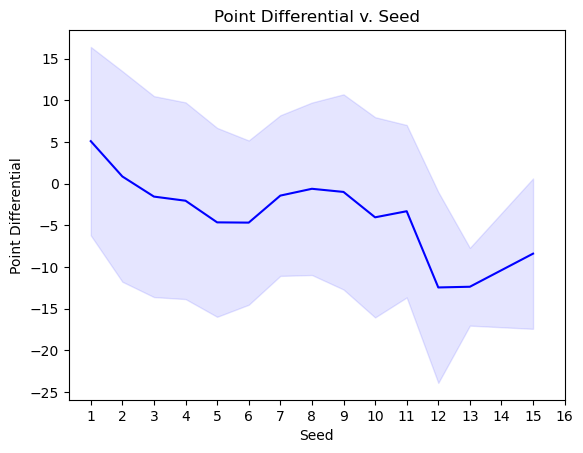

In [91]:
# Visualize how good of a metric seed is for predicting outcome
mu_seed = M_sweet_onwards_data.pivot_table(index = "T1_seed", values = "PointDiff", aggfunc = "mean").ffill()
sigma_seed =  M_sweet_onwards_data.pivot_table(index = "T1_seed", values = "PointDiff", aggfunc = "std").ffill()

bottom = list((mu_seed - sigma_seed)['PointDiff'])
top = list((mu_seed + sigma_seed)['PointDiff'])

plt.plot(mu_seed.index, mu_seed, 'b-')
plt.fill_between(mu_seed.index,bottom, top, color="b", alpha=0.1)
plt.xlabel('Seed')
plt.ylabel('Point Differential')
plt.xticks(list(range(1,17)))
plt.title("Point Differential v. Seed")

Text(0.5, 1.0, 'Point Differential v. Seed Differential')

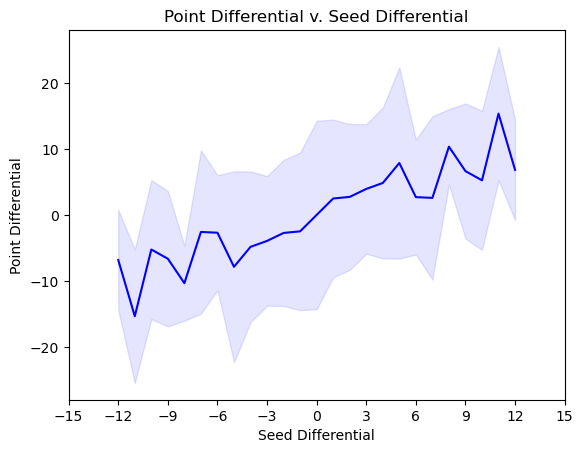

In [92]:
# Visualize how good of a metrics seed differential is for predicting outcome
mu_seed_diff = M_sweet_onwards_data.pivot_table(index = "seed_Diff", values = "PointDiff", aggfunc = "mean").ffill()
sigma_seed_diff =  M_sweet_onwards_data.pivot_table(index = "seed_Diff", values = "PointDiff", aggfunc = "std").ffill()

bottom = list((mu_seed_diff - sigma_seed_diff)['PointDiff'])
top = list((mu_seed_diff + sigma_seed_diff)['PointDiff'])

plt.plot(mu_seed_diff.index, mu_seed_diff, 'b-')
plt.fill_between(mu_seed_diff.index,bottom, top, color="b", alpha=0.1)
plt.xlabel('Seed Differential')
plt.ylabel('Point Differential')
plt.xticks(list(range(-15,16,3)))
plt.title("Point Differential v. Seed Differential")

In [93]:
import numpy as np

def pagerank(M, d: float = 0.85):
    """PageRank Algorithm that treats teams as nodes, and outcome in their games as a link
    If Team a loses to Team b >= 1 time during the regular season, 
        This is an event where we demarcate power flow from Team a to Team b
        For Team A, we consider all its losses during the season
            For multiple losses against same team, take average point differential to aggregate
            Compute sum of all margins of loss and normalize each differential with that sum
            Set its column vector based on those calculations
                Team A loses to Team B by avg of 7.5 pts p game during regular season:
                    Entry at column A, Row B of 7.5 / total differential across all losses 
                    (accounting for normalization for losses to same team)
    
    Use the Power Calculation, applying fundamentals of linear algebra

    Parameters
    ----------
    M : numpy array
        adjacency matrix where M_i,j represents the link from 'j' to 'i', such that for all 'j'
        sum(i, M_i,j) = 1

    d : float, optional
        damping factor

    Returns
    -------
    numpy array
        a vector of ranks such that v_i is the i-th rank score (takes on values from  [0, 1]),
        the sum of the values in this array is 1.0

    """
    N = M.shape[1]
    w = np.ones(N) / N
    M_hat = d * M
    v = M_hat @ w + (1 - d) / N
    while np.linalg.norm(w - v) >= 1e-20:
        w = v
        v = M_hat @ w + (1 - d) / N
    return v

In [94]:
M_before_sweet_data

,Season,DayNum,T2_TeamID,T2_Score,T1_TeamID,T1_Score,NumOT,T2_FGM,T2_FGA,T2_FGM3,T2_FGA3,T2_FTM,T2_FTA,T2_OR,T2_DR,T2_Ast,T2_TO,T2_Stl,T2_Blk,T2_PF,T1_FGM,T1_FGA,T1_FGM3,T1_FGA3,T1_FTM,T1_FTA,T1_OR,T1_DR,T1_Ast,T1_TO,T1_Stl,T1_Blk,T1_PF,PointDiff,win
0,2003,10,1328,62.0,1104,68.0,0,22.0,53.0,2.0,10.0,16.0,22.0,10.0,22.0,8.0,18.0,9.0,2.0,20.0,27.0,58.0,3.0,14.0,11.0,18.0,14.0,24.0,13.0,23.0,7.0,1.0,22.0,6.0,1
1,2003,10,1393,63.0,1272,70.0,0,24.0,67.0,6.0,24.0,9.0,20.0,20.0,25.0,7.0,12.0,8.0,6.0,16.0,26.0,62.0,8.0,20.0,10.0,19.0,15.0,28.0,16.0,13.0,4.0,4.0,18.0,7.0,1
2,2003,11,1437,61.0,1266,73.0,0,22.0,73.0,3.0,26.0,14.0,23.0,31.0,22.0,9.0,12.0,2.0,5.0,23.0,24.0,58.0,8.0,18.0,17.0,29.0,17.0,26.0,15.0,10.0,5.0,2.0,25.0,12.0,1
3,2003,11,1457,50.0,1296,56.0,0,18.0,49.0,6.0,22.0,8.0,15.0,17.0,20.0,9.0,19.0,4.0,3.0,23.0,18.0,38.0,3.0,9.0,17.0,31.0,6.0,19.0,11.0,12.0,14.0,2.0,18.0,6.0,1
4,2003,11,1208,71.0,1400,77.0,0,24.0,62.0,6.0,16.0,17.0,27.0,21.0,15.0,12.0,10.0,7.0,1.0,14.0,30.0,61.0,6.0,14.0,11.0,13.0,17.0,22.0,12.0,14.0,4.0,4.0,20.0,6.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251291,2025,139,1196,77.0,1163,75.0,0,23.0,50.0,9.0,19.0,22.0,34.0,11.0,28.0,12.0,12.0,4.0,0.0,17.0,24.0,64.0,8.0,29.0,19.0,22.0,14.0,21.0,16.0,6.0,8.0,2.0,21.0,-2.0,0
251292,2025,139,1246,84.0,1228,75.0,0,32.0,68.0,8.0,21.0,12.0,20.0,8.0,26.0,18.0,5.0,14.0,4.0,18.0,27.0,62.0,9.0,32.0,12.0,19.0,11.0,29.0,12.0,14.0,3.0,5.0,20.0,-9.0,0
251293,2025,139,1268,72.0,1161,71.0,0,26.0,62.0,10.0,24.0,10.0,12.0,6.0,20.0,11.0,5.0,6.0,4.0,7.0,29.0,62.0,5.0,21.0,8.0,10.0,12.0,24.0,15.0,8.0,3.0,4.0,14.0,-1.0,0
251294,2025,139,1277,71.0,1307,63.0,0,24.0,54.0,4.0,15.0,19.0,28.0,9.0,22.0,14.0,9.0,6.0,7.0,11.0,27.0,56.0,4.0,13.0,5.0,10.0,6.0,22.0,7.0,9.0,5.0,1.0,22.0,-8.0,0


In [95]:
def get_pagerank_info(year):
    return M_before_sweet[M_before_sweet["Season"] == year][["WTeamID", "WScore", "LTeamID", "LScore"]]

years = list(range(2003, 2026))
years.remove(2020)

M_pagerank = pd.DataFrame()

for year_idx in tqdm(range(len(years))):

    year = years[year_idx]

    distinct_team_ids = []
    winner_id_list = get_pagerank_info(year)["WTeamID"].tolist()

    loser_id_list = get_pagerank_info(year)["LTeamID"].tolist()


    id_list = list(set(winner_id_list + loser_id_list))
    idx_map = dict()


    for i in range(len(id_list)):
        idx_map[id_list[i]] = i

    N = len(id_list)

    M = np.zeros((N, N))

    for curr_team in id_list:

        df = get_pagerank_info(year)

        loss_res = df[df["LTeamID"] == curr_team]

        loss_res["Diff"] = loss_res["WScore"] - loss_res["LScore"]
        loss_res["Opp_Team"] = loss_res["WTeamID"]
        loss_res['Curr_Team'] = curr_team
        loss_res = loss_res.reset_index()

        loss_res['Avg_Diff'] = loss_res.groupby(['Curr_Team', 'Opp_Team'])['Diff'].transform('mean')
        loss_res = loss_res.drop_duplicates(['Curr_Team', 'Opp_Team'])

        total_loss_diff = loss_res['Avg_Diff'].sum()

        loss_res['Norm_Diff'] = loss_res['Avg_Diff'] / total_loss_diff

        loss_res = loss_res[['Curr_Team', 'Opp_Team', 'Norm_Diff']]

        for index, row in loss_res.iterrows():
            c = idx_map[curr_team]
            r = idx_map[int(row['Opp_Team'])]
            M[r, c] += row['Norm_Diff']

    v = pagerank(M, 0.1) # between 0 and 1

    idx_power_list = []

    for i, x in enumerate(v):
        idx_power_list.append((i,x))

    idx_power_list.sort(key = lambda x: x[1], reverse = True)

    M_pagerank_year = pd.DataFrame({'PR_Power' : [x[1] for x in idx_power_list], 'TeamID' : [id_list[x[0]] for x in idx_power_list]})
    M_pagerank_year['Season'] = year

    M_pagerank = pd.concat([M_pagerank, M_pagerank_year])

100%|██████████| 22/22 [00:19<00:00,  1.14it/s]


In [96]:
M_pagerank

,PR_Power,TeamID,Season
0,0.003902,1257,2003
1,0.003893,1338,2003
2,0.003853,1242,2003
3,0.003822,1268,2003
4,0.003813,1246,2003
...,...,...,...
359,0.002495,1115,2025
360,0.002494,1170,2025
361,0.002494,1271,2025
362,0.002488,1154,2025


In [97]:
T1_PR = M_pagerank[["Season", "TeamID", "PR_Power"]].copy()
T2_PR = M_pagerank[["Season", "TeamID", "PR_Power"]].copy()

T1_PR.columns = ["Season", "T1_TeamID", "T1_PageRank"]
T2_PR.columns = ["Season", "T2_TeamID", "T2_PageRank"]

M_sweet_onwards_data_slice = M_sweet_onwards_data[["Season", "T1_TeamID", "T2_TeamID", "PointDiff", "win"]]

M_sweet_onwards_data_slice = pd.merge(M_sweet_onwards_data_slice, T1_PR, on=["Season", "T1_TeamID"], how = "left")
M_sweet_onwards_data_slice = pd.merge(M_sweet_onwards_data_slice, T2_PR, on=["Season", "T2_TeamID"], how = "left")

M_sweet_onwards_data_slice["PageRank_Diff"] = M_sweet_onwards_data_slice["T2_PageRank"] - M_sweet_onwards_data_slice["T1_PageRank"]
M_sweet_onwards_data = pd.merge(M_sweet_onwards_data, M_sweet_onwards_data_slice, on = ["Season", "T1_TeamID", "T2_TeamID", "PointDiff", "win"], how = "left")
M_sweet_onwards_data

,Season,T1_TeamID,T2_TeamID,PointDiff,win,T1_seed,T2_seed,seed_Diff,T1_PageRank,T2_PageRank,PageRank_Diff
0,2003,1112,1323,17.0,1,1,5,4,0.003741,0.003766,0.000024
1,2003,1242,1181,4.0,1,2,3,1,0.003853,0.003805,-0.000048
2,2003,1246,1458,6.0,1,1,5,4,0.003813,0.003610,-0.000203
3,2003,1266,1338,3.0,1,3,2,-1,0.003510,0.003893,0.000383
4,2003,1277,1268,2.0,1,7,6,-1,0.003552,0.003822,0.000270
...,...,...,...,...,...,...,...,...,...,...,...
655,2025,1277,1120,-6.0,0,2,1,-1,0.003295,0.003691,0.000396
656,2025,1397,1222,-19.0,0,2,1,-1,0.003596,0.003477,-0.000119
657,2025,1120,1196,-6.0,0,1,1,0,0.003691,0.003832,0.000141
658,2025,1181,1222,-3.0,0,1,1,0,0.003834,0.003477,-0.000356


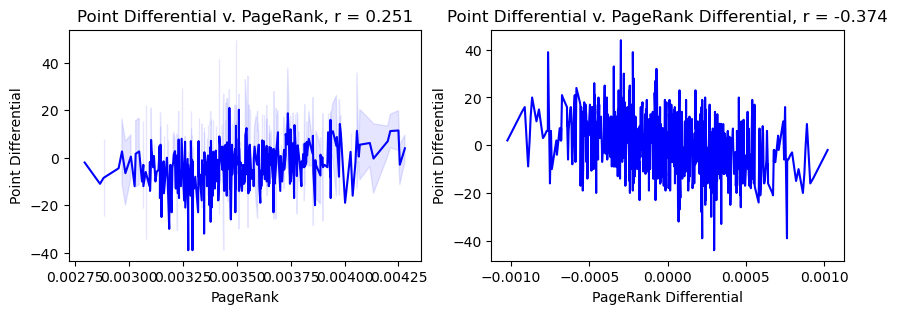

In [98]:
# Helper function that takes in a stat_name and start_year as input
# Plots and Displays Point Differential v. Raw Stat and Point Differential v. Stat Differential
def visualize_stat_correlation(stat_name, start_year = 2003):

    # Visualize how good of a metric the raw stat is for predicting outcome

    subset_tourney_data = M_sweet_onwards_data.loc[M_sweet_onwards_data["Season"] >= start_year].copy()

    corr_df = subset_tourney_data[["PointDiff", f"T1_{stat_name}"]].copy()
    r = corr_df.corr().iloc[0,1]

    mu_stat = subset_tourney_data.pivot_table(index = f"T1_{stat_name}", values = "PointDiff", aggfunc = "mean").ffill()
    sigma_stat = subset_tourney_data.pivot_table(index = f"T1_{stat_name}", values = "PointDiff", aggfunc = "std").ffill()

    bottom = list((mu_stat - sigma_stat)['PointDiff'])
    top = list((mu_stat + sigma_stat)['PointDiff'])

    fig, axs = plt.subplots(1, 2)
    fig.set_figheight(3)
    fig.set_figwidth(10)

    condensed_stat_name = stat_name if not "opponent" in stat_name else stat_name[:7] + stat_name[12:]

    axs[0].plot(mu_stat.index, mu_stat, 'b-')
    axs[0].fill_between(mu_stat.index,bottom, top, color="b", alpha=0.1)
    axs[0].set_xlabel(condensed_stat_name)
    axs[0].set_ylabel('Point Differential')
    axs[0].set_title(f"Point Differential v. {condensed_stat_name}, r = {r:.3f}")

    # Visualize how good of a metrics stat differential is for predicting outcome

    subset_tourney_data[f"{stat_name}_Diff"] = subset_tourney_data[f"T2_{stat_name}"] -  subset_tourney_data[f"T1_{stat_name}"]

    corr_diff_df = subset_tourney_data[["PointDiff", f"{stat_name}_Diff"]].copy()
    r_diff = corr_diff_df.corr().iloc[0,1]

    mu_seed_diff = subset_tourney_data.pivot_table(index = f"{stat_name}_Diff", values = "PointDiff", aggfunc = "mean").ffill()
    sigma_seed_diff =  subset_tourney_data.pivot_table(index = f"{stat_name}_Diff", values = "PointDiff", aggfunc = "std").ffill()

    bottom = list((mu_seed_diff - sigma_seed_diff)['PointDiff'])
    top = list((mu_seed_diff + sigma_seed_diff)['PointDiff'])

    axs[1].plot(mu_seed_diff.index, mu_seed_diff, 'b-')
    axs[1].fill_between(mu_seed_diff.index,bottom, top, color="b", alpha=0.1)
    axs[1].set_xlabel(f'{condensed_stat_name} Differential')
    axs[1].set_ylabel('Point Differential')
    axs[1].set_title(f"Point Differential v. {condensed_stat_name} Differential, r = {r_diff:.3f}")

    plt.show()

visualize_stat_correlation("PageRank")

In [99]:
M_sweet_onwards_data

,Season,T1_TeamID,T2_TeamID,PointDiff,win,T1_seed,T2_seed,seed_Diff,T1_PageRank,T2_PageRank,PageRank_Diff
0,2003,1112,1323,17.0,1,1,5,4,0.003741,0.003766,0.000024
1,2003,1242,1181,4.0,1,2,3,1,0.003853,0.003805,-0.000048
2,2003,1246,1458,6.0,1,1,5,4,0.003813,0.003610,-0.000203
3,2003,1266,1338,3.0,1,3,2,-1,0.003510,0.003893,0.000383
4,2003,1277,1268,2.0,1,7,6,-1,0.003552,0.003822,0.000270
...,...,...,...,...,...,...,...,...,...,...,...
655,2025,1277,1120,-6.0,0,2,1,-1,0.003295,0.003691,0.000396
656,2025,1397,1222,-19.0,0,2,1,-1,0.003596,0.003477,-0.000119
657,2025,1120,1196,-6.0,0,1,1,0,0.003691,0.003832,0.000141
658,2025,1181,1222,-3.0,0,1,1,0,0.003834,0.003477,-0.000356


In [100]:
M_sweet_onwards_data_slice = []
M_ranks = M_ranks[M_ranks['RankingDayNum'] == 133]

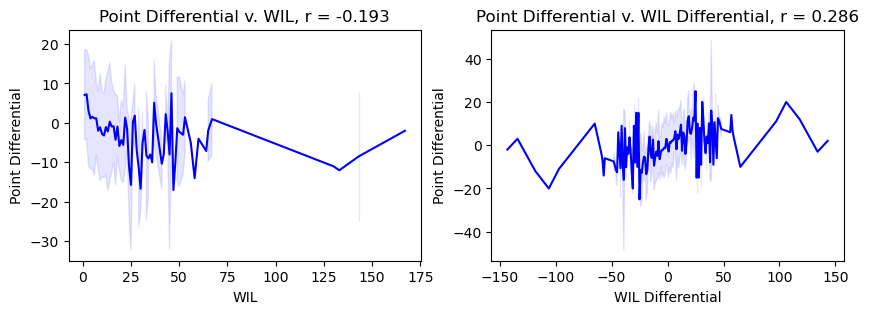

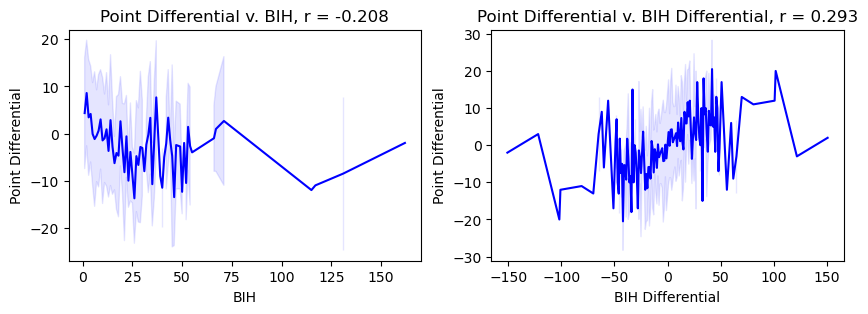

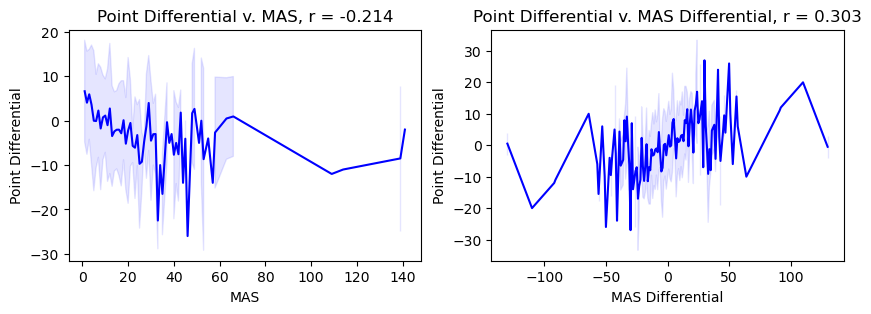

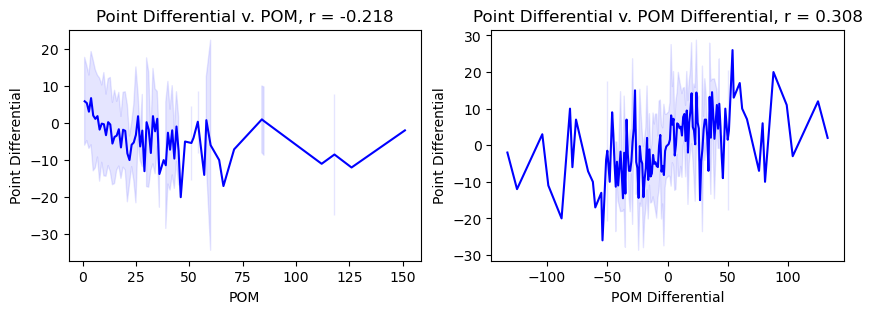

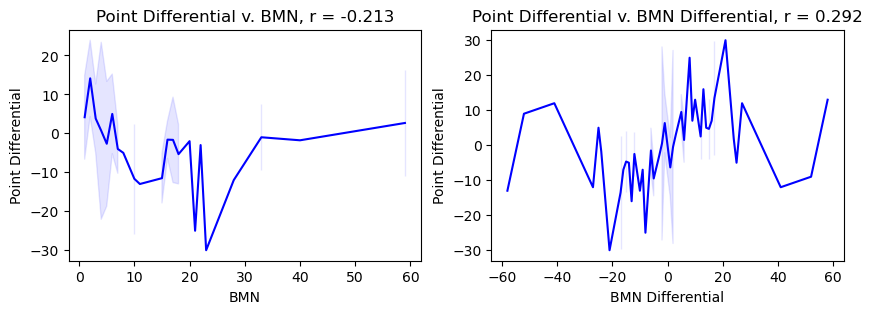

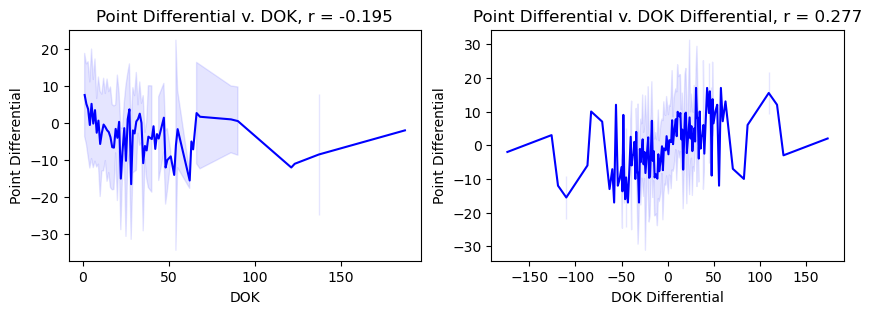

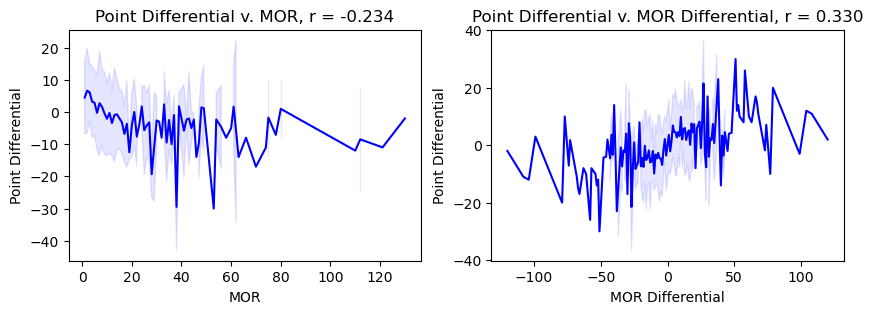

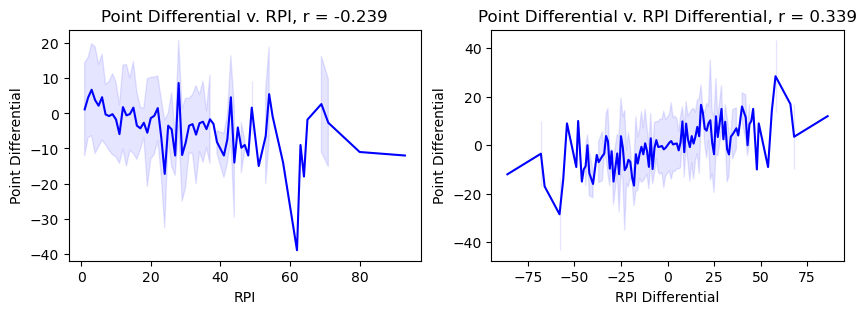

In [101]:
active_systems = ['WIL', 'BIH', 'MAS', 'POM', 'BMN', 'DOK', 'MOR', 'RPI']

for ac_sys in active_systems:

    sys_ranks = M_ranks[M_ranks['SystemName'] == ac_sys]

    # print(sys_ranks)

    rank_str = ac_sys

    T1_system = sys_ranks[["Season", "TeamID", "OrdinalRank"]].copy()
    T2_system = sys_ranks[["Season", "TeamID", "OrdinalRank"]].copy()

    T1_system.columns = ["Season", "T1_TeamID", f"T1_{rank_str}"]
    T2_system.columns = ["Season", "T2_TeamID", f"T2_{rank_str}"]


    M_sweet_onwards_data_slice = M_sweet_onwards_data[["Season", "T1_TeamID", "T2_TeamID", "PointDiff", "win"]]


    M_sweet_onwards_data_slice = pd.merge(M_sweet_onwards_data_slice, T1_system, on=["Season", "T1_TeamID"], how = "left")


    M_sweet_onwards_data_slice = pd.merge(M_sweet_onwards_data_slice, T2_system, on=["Season", "T2_TeamID"], how = "left")


    M_sweet_onwards_data_slice[f"{rank_str}_Diff"] = M_sweet_onwards_data_slice[f"T2_{rank_str}"] - M_sweet_onwards_data_slice[f"T1_{rank_str}"]


    M_sweet_onwards_data = pd.merge(M_sweet_onwards_data, M_sweet_onwards_data_slice, on = ["Season", "T1_TeamID", "T2_TeamID", "PointDiff", "win"], how = "left")

    visualize_stat_correlation(ac_sys)

In [103]:
# list which stats we want to aggregate acros the season for each team 
#   - calculate all interesting features
box_score_stats = [
    "T1_Score", "T1_FGM", "T1_FGA", "T1_FGM3", "T1_FGA3", "T1_FTM", "T1_FTA",
    "T1_OR", "T1_DR", "T1_Ast", "T1_TO", "T1_Stl", "T1_Blk", "T1_PF",
    "T2_Score", "T2_FGM", "T2_FGA", "T2_FGM3", "T2_FGA3", "T2_FTM", "T2_FTA",
    "T2_OR", "T2_DR", "T2_Ast", "T2_TO", "T2_Stl", "T2_Blk", "T2_PF",
    "PointDiff"
]

In [104]:
# aggregate the average statistics for every team across the season and concatenate the corresponding
# columns on the tournament matchup data
season_stats = M_before_sweet_data.groupby(["Season", "T1_TeamID"])[box_score_stats].agg("mean").reset_index()

season_stats_T1 = season_stats.copy()
season_stats_T1.columns = ["T1_avg_" + x.replace("T1_", "").replace("T2_", "opponent_") for x in list(season_stats_T1.columns)]
season_stats_T1 = season_stats_T1.rename({"T1_avg_Season" : "Season", "T1_avg_TeamID" : "T1_TeamID"}, axis = 1)

season_stats_T2 = season_stats.copy()
season_stats_T2.columns = ["T2_avg_" + x.replace("T1_", "").replace("T2_", "opponent_") for x in list(season_stats_T2.columns)]
season_stats_T2 = season_stats_T2.rename({"T2_avg_Season" : "Season", "T2_avg_TeamID" : "T2_TeamID"}, axis = 1)

M_sweet_onwards_data = pd.merge(M_sweet_onwards_data, season_stats_T1, on = ["Season", "T1_TeamID"], how = "left")
M_sweet_onwards_data = pd.merge(M_sweet_onwards_data, season_stats_T2, on = ["Season", "T2_TeamID"], how = "left")
M_sweet_onwards_data

,Season,T1_TeamID,T2_TeamID,PointDiff,win,T1_seed,T2_seed,seed_Diff,T1_PageRank,T2_PageRank,PageRank_Diff,T1_WIL,T2_WIL,WIL_Diff,T1_BIH,T2_BIH,BIH_Diff,T1_MAS,T2_MAS,MAS_Diff,T1_POM,T2_POM,POM_Diff,T1_BMN,T2_BMN,BMN_Diff,T1_DOK,T2_DOK,DOK_Diff,T1_MOR,T2_MOR,MOR_Diff,T1_RPI,T2_RPI,RPI_Diff,T1_avg_Score,T1_avg_FGM,T1_avg_FGA,T1_avg_FGM3,T1_avg_FGA3,T1_avg_FTM,T1_avg_FTA,T1_avg_OR,T1_avg_DR,T1_avg_Ast,T1_avg_TO,T1_avg_Stl,T1_avg_Blk,T1_avg_PF,T1_avg_opponent_Score,T1_avg_opponent_FGM,T1_avg_opponent_FGA,T1_avg_opponent_FGM3,T1_avg_opponent_FGA3,T1_avg_opponent_FTM,T1_avg_opponent_FTA,T1_avg_opponent_OR,T1_avg_opponent_DR,T1_avg_opponent_Ast,T1_avg_opponent_TO,T1_avg_opponent_Stl,T1_avg_opponent_Blk,T1_avg_opponent_PF,T1_avg_PointDiff,T2_avg_Score,T2_avg_FGM,T2_avg_FGA,T2_avg_FGM3,T2_avg_FGA3,T2_avg_FTM,T2_avg_FTA,T2_avg_OR,T2_avg_DR,T2_avg_Ast,T2_avg_TO,T2_avg_Stl,T2_avg_Blk,T2_avg_PF,T2_avg_opponent_Score,T2_avg_opponent_FGM,T2_avg_opponent_FGA,T2_avg_opponent_FGM3,T2_avg_opponent_FGA3,T2_avg_opponent_FTM,T2_avg_opponent_FTA,T2_avg_opponent_OR,T2_avg_opponent_DR,T2_avg_opponent_Ast,T2_avg_opponent_TO,T2_avg_opponent_Stl,T2_avg_opponent_Blk,T2_avg_opponent_PF,T2_avg_PointDiff
0,2003,1112,1323,17.0,1,1,5,4,0.003741,0.003766,0.000024,NaN,NaN,NaN,2.0,21.0,19.0,3.0,23.0,20.0,3,22,19,NaN,NaN,NaN,NaN,NaN,NaN,4,36,32,2.0,14.0,12.0,84.104444,30.002963,64.921481,6.938519,19.940000,17.160000,24.399259,14.894815,27.584444,17.535556,14.462222,8.357037,4.247407,17.214815,69.129630,25.947407,64.020000,6.263704,19.811111,10.971111,17.130370,12.808148,23.116296,15.251852,16.482222,5.977778,2.444444,21.596296,14.974815,78.520539,26.777778,59.836364,8.190572,21.348148,16.774411,21.955556,11.046465,26.926599,16.284848,12.802694,7.257912,5.555556,16.010101,69.907071,26.205387,64.070707,6.182492,17.057912,11.313805,16.548148,13.446465,24.622222,14.932660,12.761616,6.610774,4.349495,19.057239,8.613468
1,2003,1242,1181,4.0,1,2,3,1,0.003853,0.003805,-0.000048,NaN,NaN,NaN,9.0,11.0,2.0,5.0,10.0,5.0,4,8,4,NaN,NaN,NaN,NaN,NaN,NaN,2,10,8,6.0,12.0,6.0,81.625000,30.468750,61.843750,4.718750,13.718750,15.968750,24.031250,14.000000,26.718750,16.750000,14.718750,9.937500,4.906250,16.812500,66.500000,24.656250,60.656250,6.531250,18.187500,10.656250,15.343750,11.750000,22.125000,11.906250,16.968750,6.812500,4.312500,19.875000,15.125000,81.125000,27.106250,59.418750,7.275000,19.993750,19.637500,27.550000,13.318750,23.106250,13.506250,13.900000,8.718750,5.318750,20.987500,69.068750,24.525000,56.687500,4.950000,14.375000,15.068750,21.475000,12.125000,22.343750,11.968750,17.818750,6.306250,4.000000,22.612500,12.056250
2,2003,1246,1458,6.0,1,1,5,4,0.003813,0.003610,-0.000203,NaN,NaN,NaN,1.0,23.0,22.0,1.0,20.0,19.0,1,16,15,NaN,NaN,NaN,NaN,NaN,NaN,1,15,14,1.0,25.0,24.0,77.941176,28.735294,58.500000,5.970588,16.588235,14.500000,20.411765,12.794118,24.117647,16.205882,14.000000,7.676471,5.000000,17.323529,63.794118,22.852941,55.676471,5.676471,17.441176,12.411765,18.117647,11.205882,19.735294,10.647059,16.529412,6.235294,3.411765,18.352941,14.147059,70.741935,25.129032,54.129032,6.225806,17.483871,14.258065,19.451613,10.290323,22.580645,13.354839,10.290323,6.903226,2.806452,14.741935,59.225806,22.548387,52.451613,5.064516,15.096774,9.064516,12.451613,8.741935,21.935484,11.129032,13.741935,4.516129,2.580645,18.903226,11.516129
3,2003,1266,1338,3.0,1,3,2,-1,0.003510,0.003893,0.000383,NaN,NaN,NaN,10.0,3.0,-7.0,13.0,2.0,-11.0,13,2,-11,NaN,NaN,NaN,NaN,NaN,NaN,18,3,-15,10.0,8.0,-2.0,78.244444,27.044444,55.759259,6.037037,15.244444,18.118519,23.322222,12.766667,23.792593,16.159259,13.303704,5.896296,3.488889,18.674074,67.818519,23.844444,58.474074,6.825926,20.577778,13.303704,19.155556,12.788889,18.488889,13.062963,12.274074,6.251852,2.440741,20.477778,10.425926,74.968750,27.000000,53.468750,6.375000,17.437500,14.593750,22.906250,11.218750,25.156250,17.812500,14.781250,8.281250,4.062500,17.875000,58.687500,20.437500,53.000000,5.312500,17.531250,12.500000,18.125000,10.093750,19.593

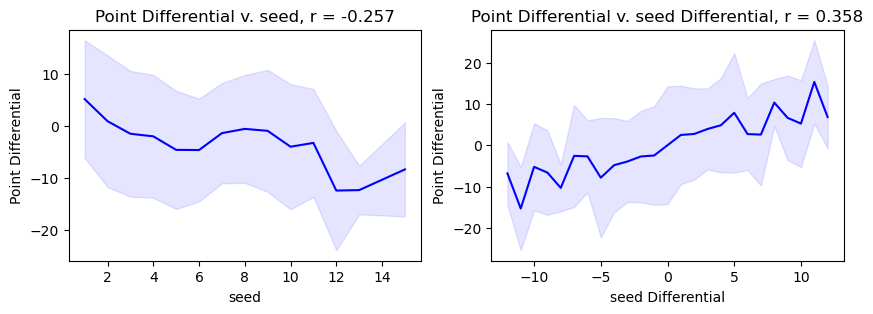

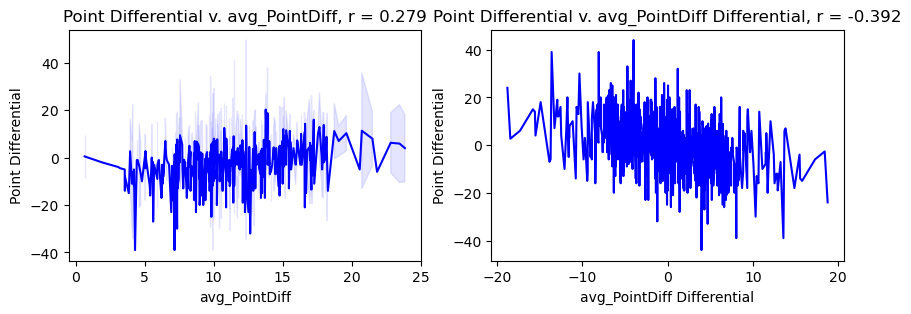

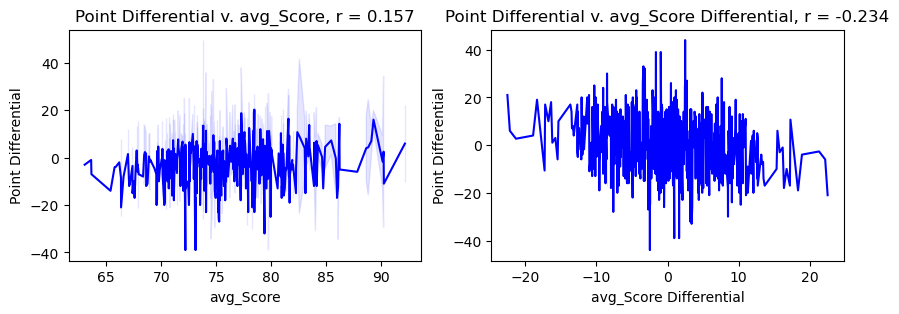

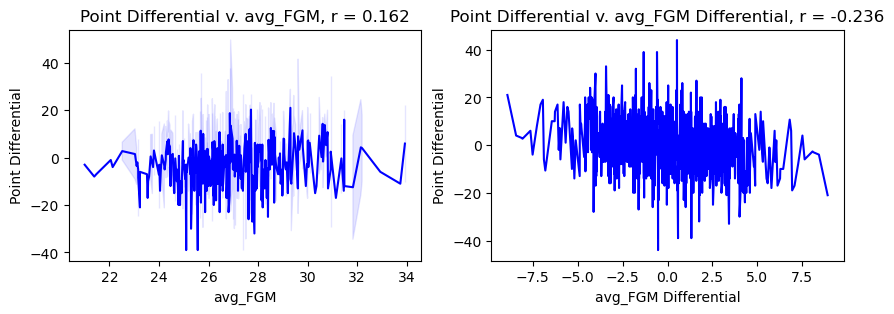

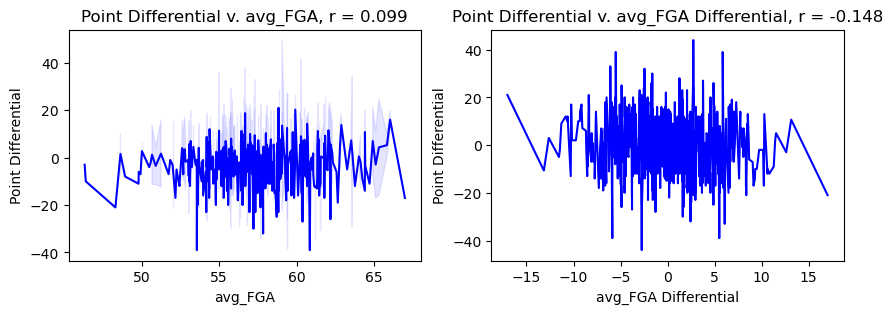

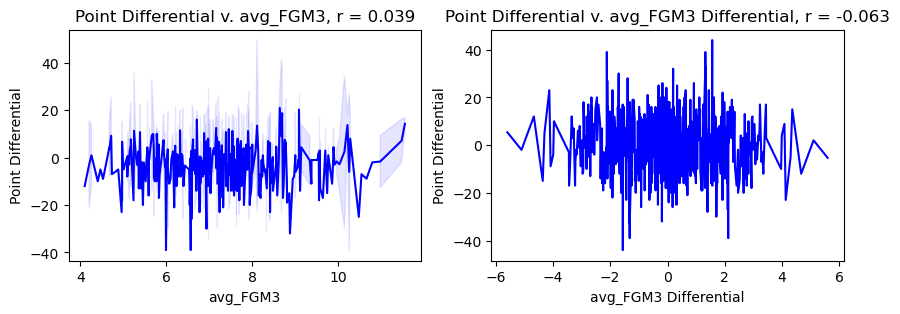

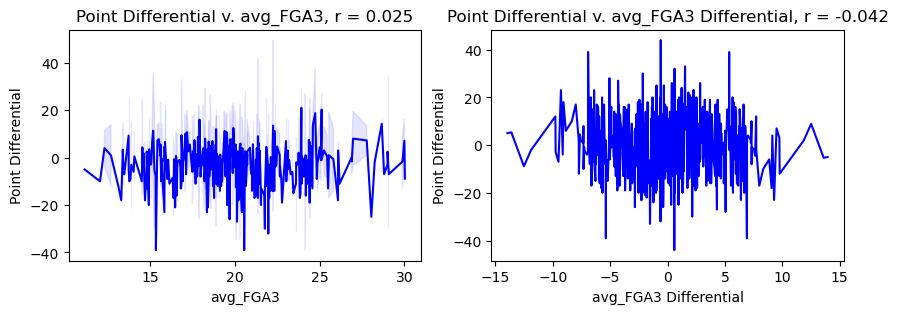

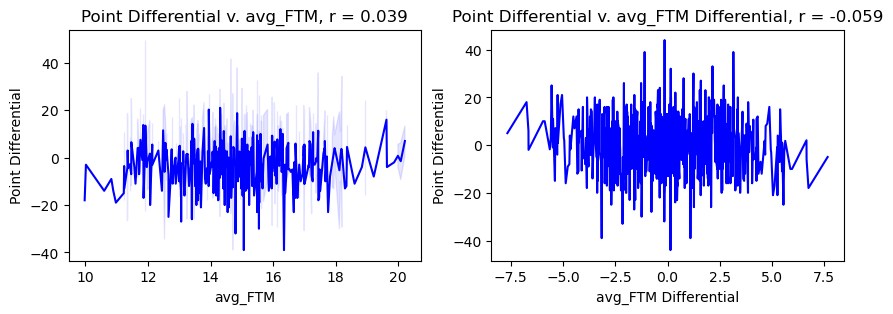

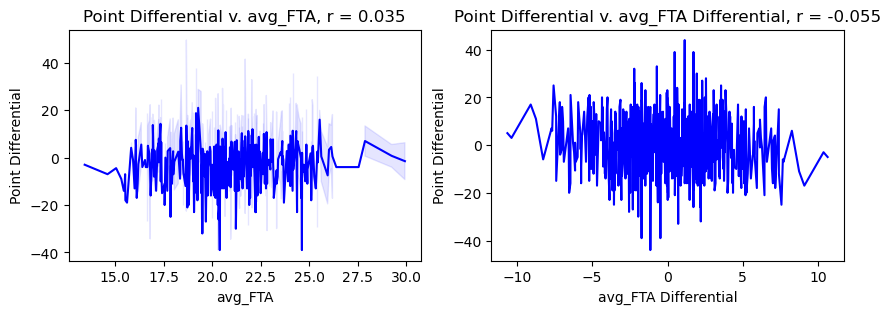

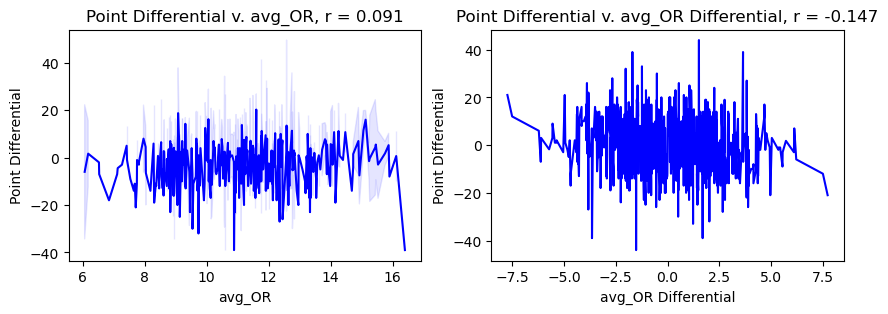

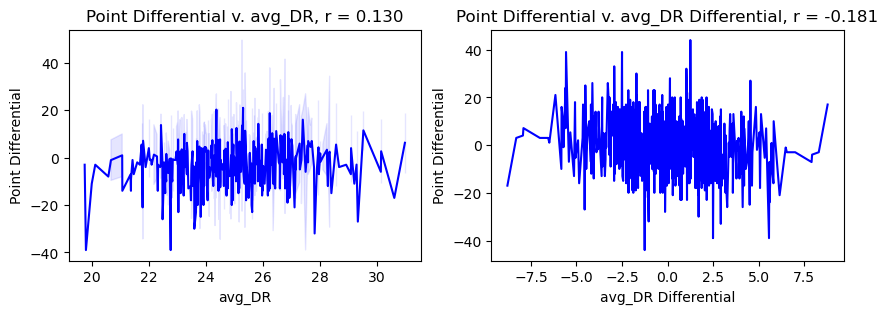

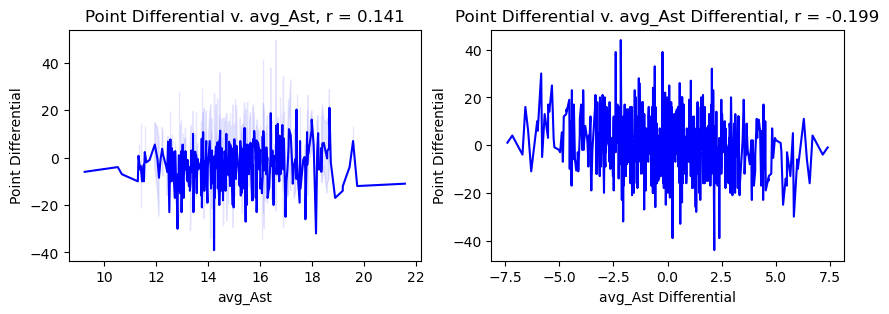

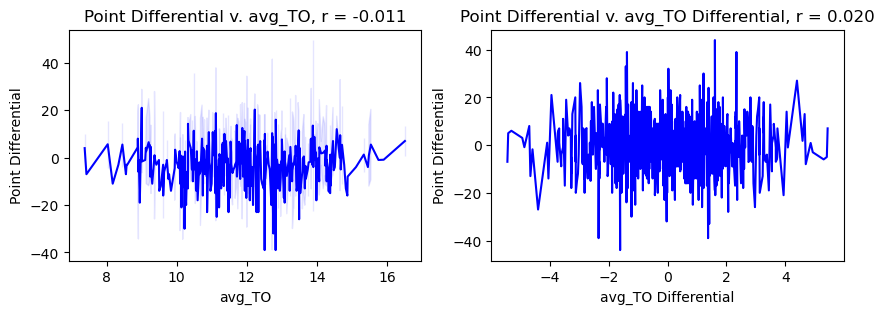

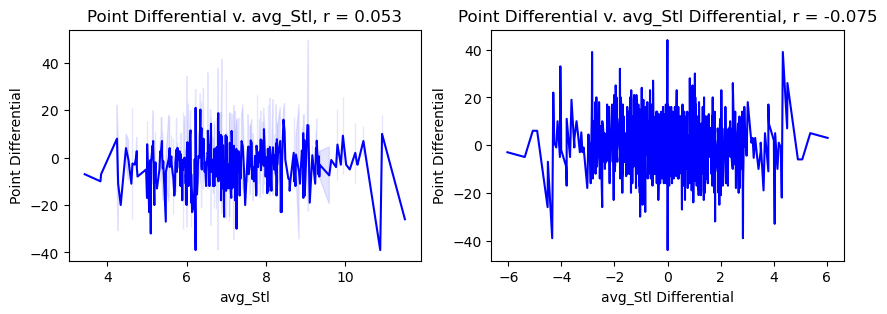

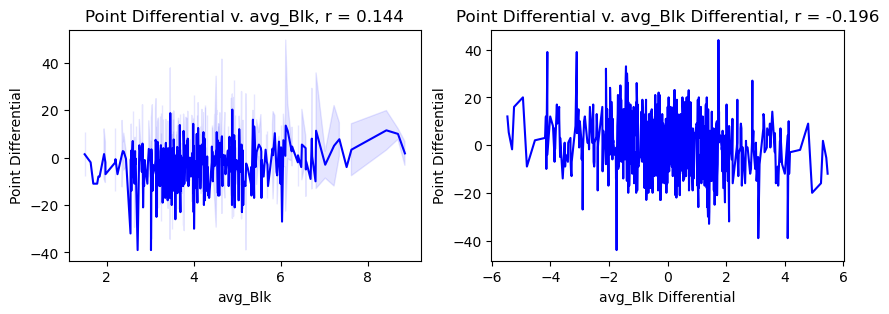

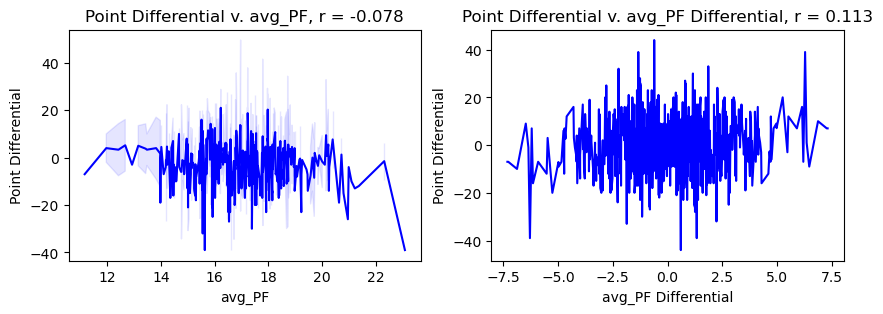

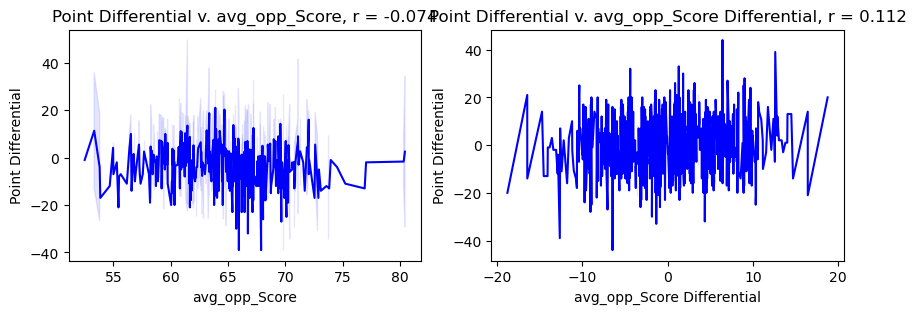

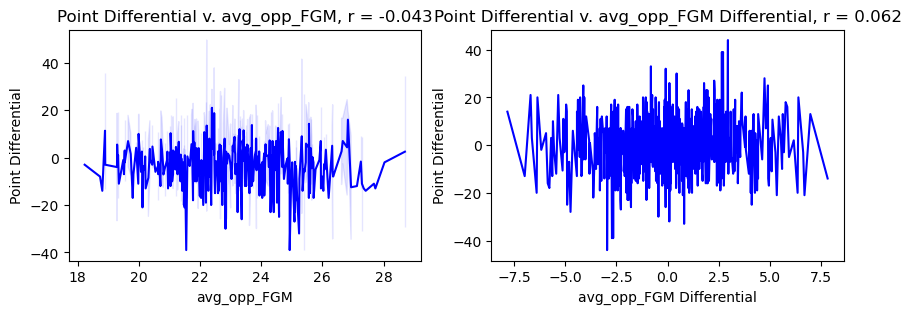

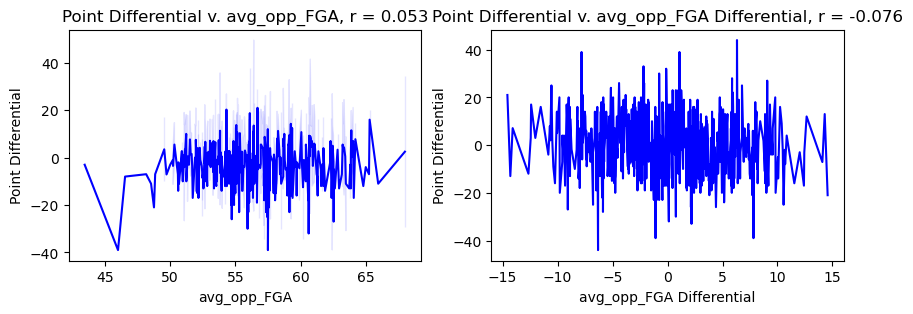

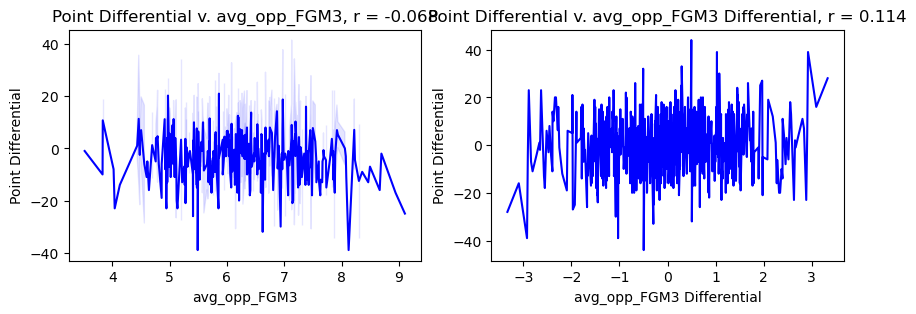

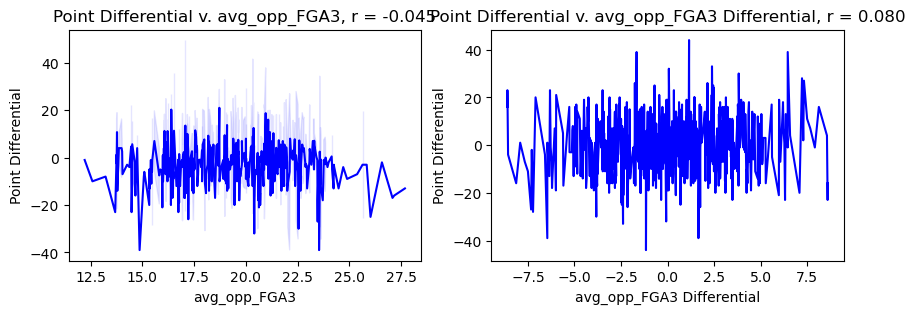

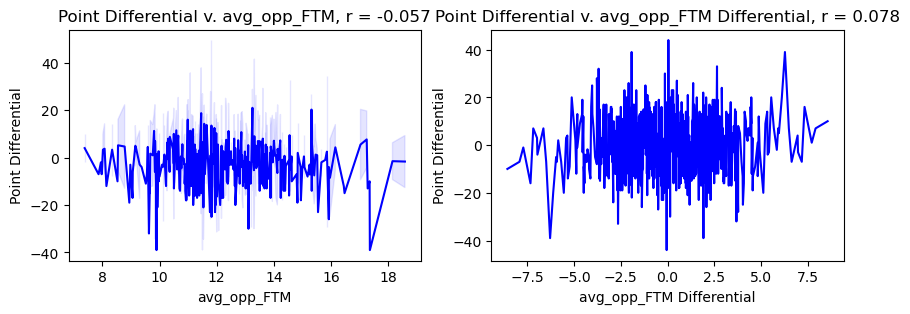

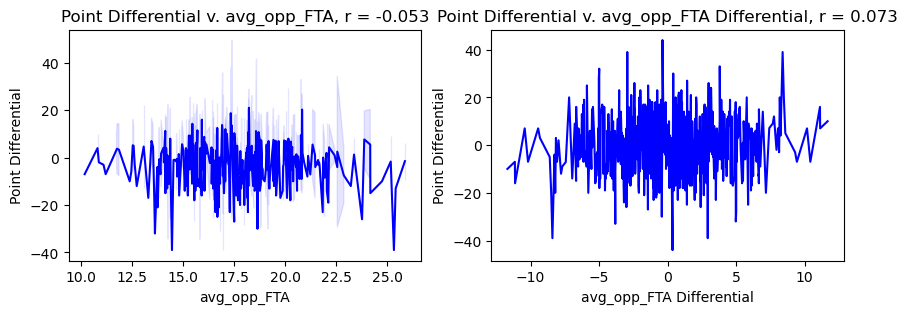

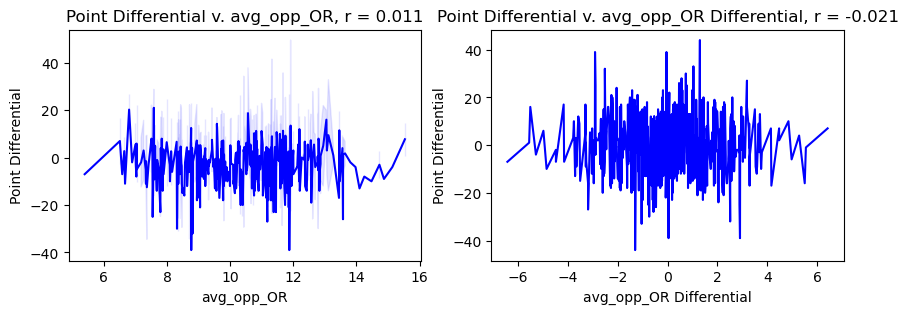

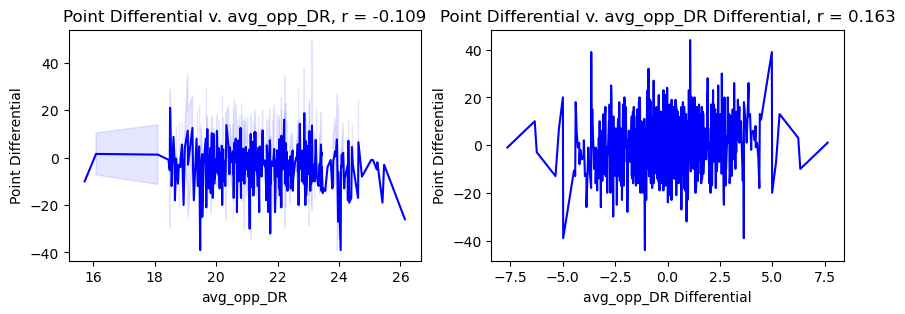

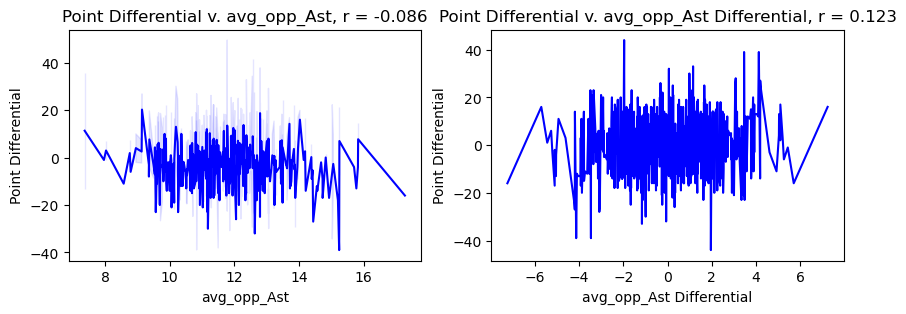

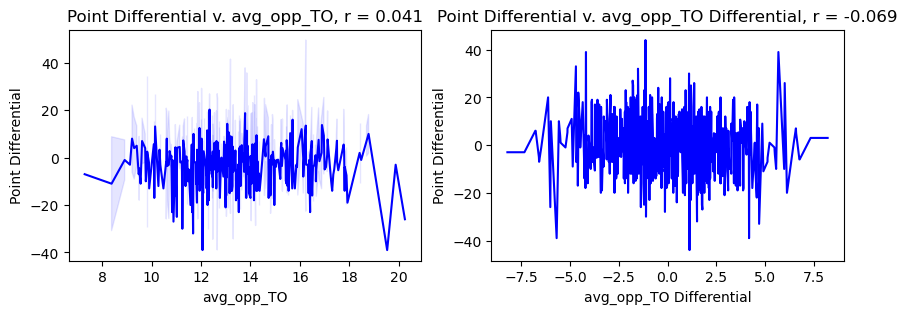

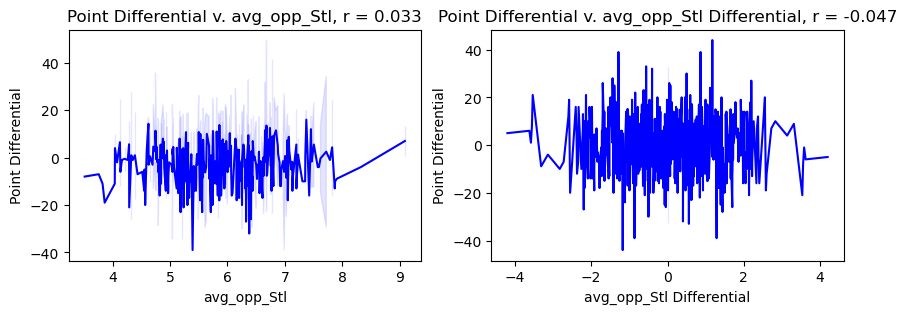

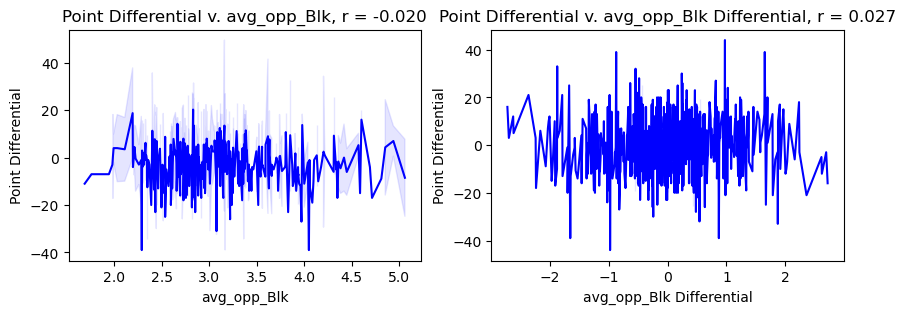

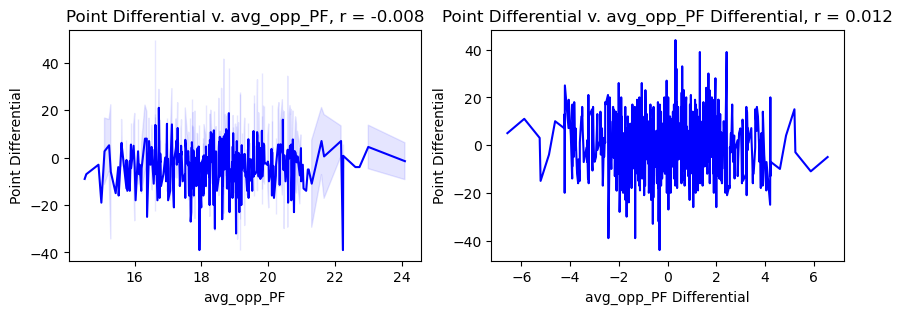

In [105]:
my_stats = ["seed", "avg_PointDiff", 'avg_Score', "avg_FGM", "avg_FGA", "avg_FGM3", "avg_FGA3", 
            "avg_FTM", "avg_FTA", 'avg_OR', "avg_DR", "avg_Ast", "avg_TO", "avg_Stl", 
            "avg_Blk", "avg_PF"]

opponent_stats = [stat[:4] + "opponent_" + stat[4:] for stat in my_stats[2:]]

for statistic in my_stats:
    visualize_stat_correlation(statistic)

for statistic in opponent_stats:
    visualize_stat_correlation(statistic)

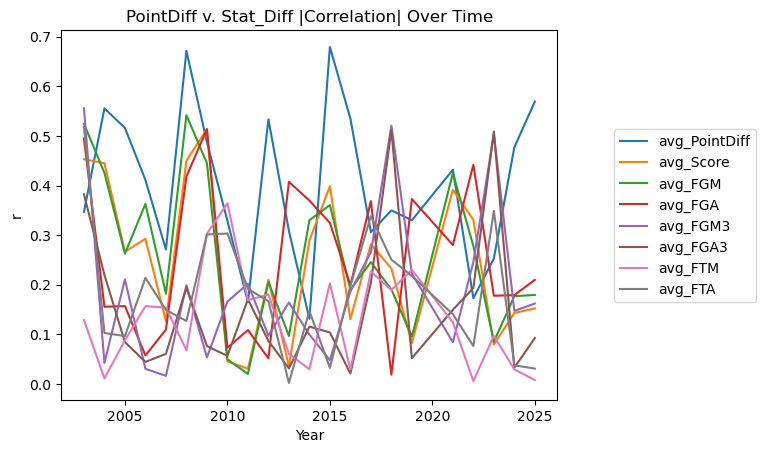

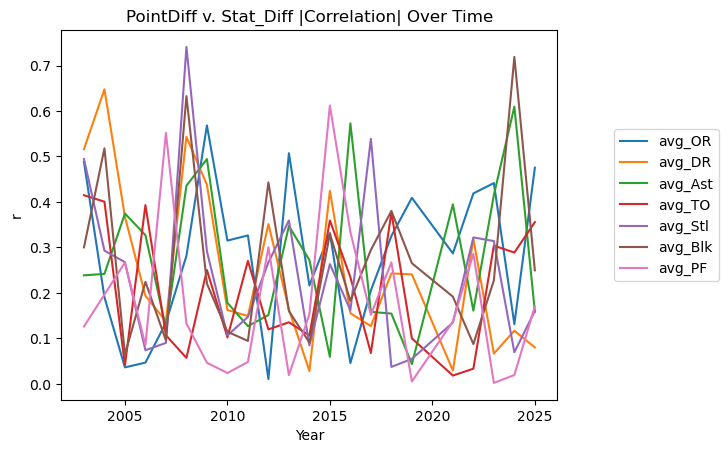

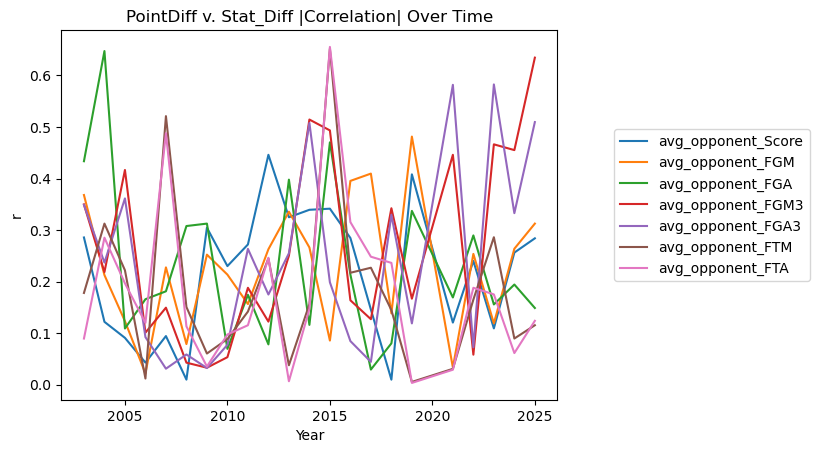

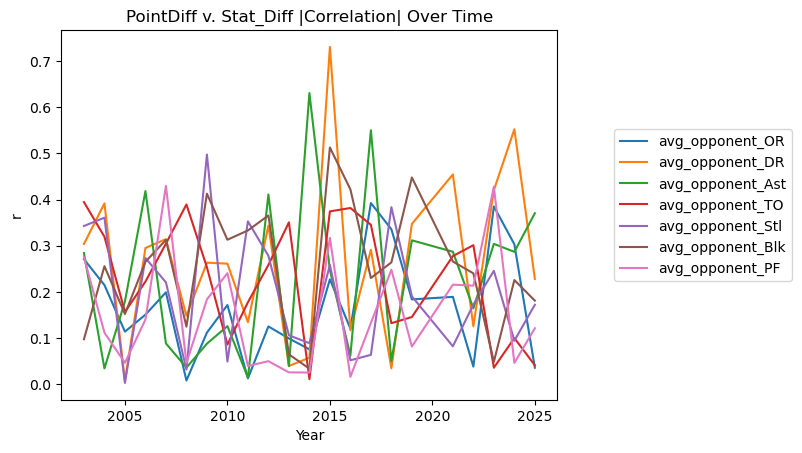

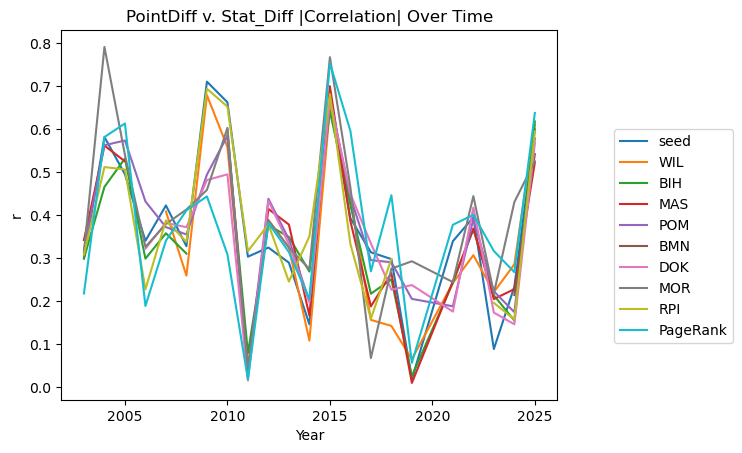

In [106]:
# Helper function that takes in a stat_name and start_year as input
# Plots and Displays Point Differential v. Raw Stat and Point Differential v. Stat Differential
def visualize_stat_correlation_over_time(stat_list):

    for stat_name in stat_list:

        years = list(range(2003, 2026))
        years.remove(2020)

        r_list = []

        for year in years:

            subset_tourney_data = M_sweet_onwards_data.loc[M_sweet_onwards_data["Season"] == year].copy()

            subset_tourney_data[f"{stat_name}_Diff"] = subset_tourney_data[f"T2_{stat_name}"] -  subset_tourney_data[f"T1_{stat_name}"]

            corr_diff_df = subset_tourney_data[["PointDiff", f"{stat_name}_Diff"]].copy()
            r_diff = corr_diff_df.corr().iloc[0,1]

            r_list.append(abs(r_diff))

        plt.plot(years, r_list, label = stat_name)
    
    plt.title(f"PointDiff v. Stat_Diff |Correlation| Over Time")
    plt.ylabel("r")
    plt.xlabel("Year")
    plt.legend(bbox_to_anchor = (1.1, 0.75))
    plt.show()


score_stats =  ["avg_PointDiff", 'avg_Score', "avg_FGM", "avg_FGA", "avg_FGM3", "avg_FGA3", 
            "avg_FTM", "avg_FTA"]

non_score_stats = ['avg_OR', "avg_DR", "avg_Ast", "avg_TO", "avg_Stl", 
            "avg_Blk", "avg_PF"]

rank_stats = ['seed'] + active_systems + ['PageRank']

opp_score_stats = [stat[:4] + "opponent_" + stat[4:] for stat in score_stats[1:]]
opp_non_score_stats = [stat[:4] + "opponent_" + stat[4:] for stat in non_score_stats]

visualize_stat_correlation_over_time(score_stats)
visualize_stat_correlation_over_time(non_score_stats)
visualize_stat_correlation_over_time(opp_score_stats)
visualize_stat_correlation_over_time(opp_non_score_stats)
visualize_stat_correlation_over_time(rank_stats)

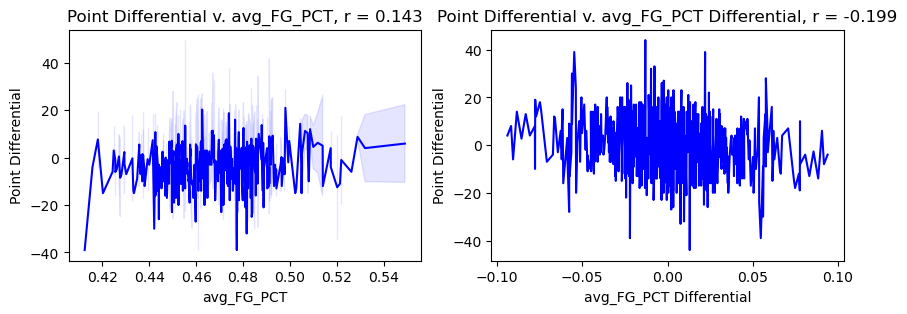

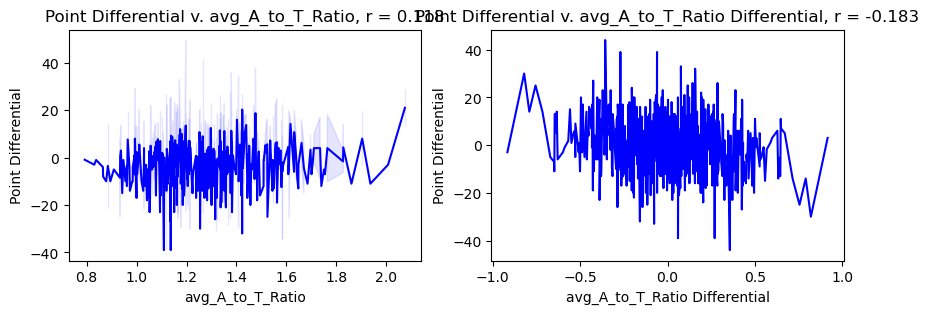

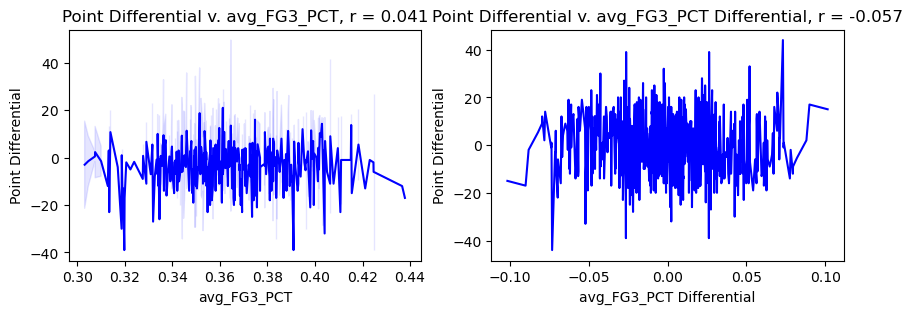

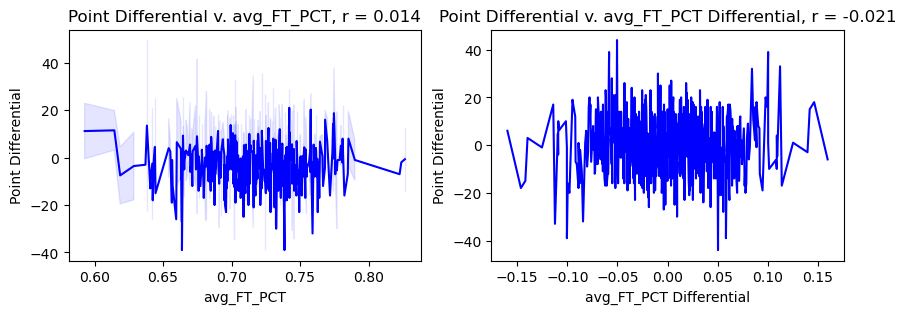

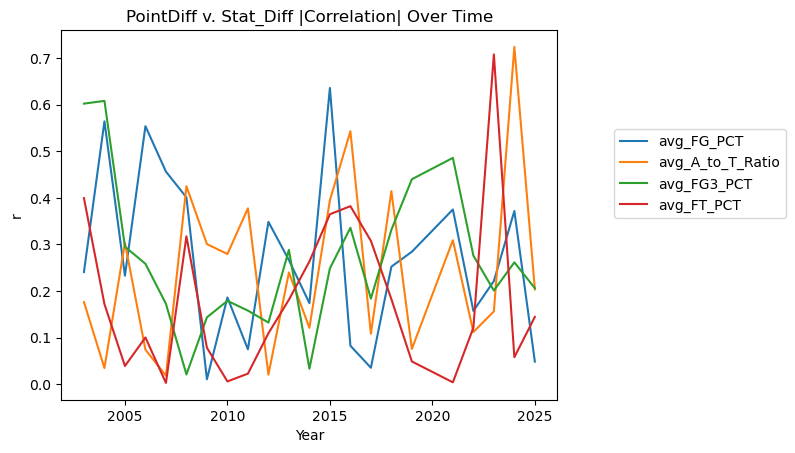

In [107]:
# try some derived metrics
M_sweet_onwards_data['T1_avg_FG_PCT'] = M_sweet_onwards_data['T1_avg_FGM'] / M_sweet_onwards_data['T1_avg_FGA']
M_sweet_onwards_data['T2_avg_FG_PCT'] = M_sweet_onwards_data['T2_avg_FGM'] / M_sweet_onwards_data['T2_avg_FGA']

M_sweet_onwards_data['T1_avg_FG3_PCT'] = M_sweet_onwards_data['T1_avg_FGM3'] / M_sweet_onwards_data['T1_avg_FGA3']
M_sweet_onwards_data['T2_avg_FG3_PCT'] = M_sweet_onwards_data['T2_avg_FGM3'] / M_sweet_onwards_data['T2_avg_FGA3']

M_sweet_onwards_data['T1_avg_FT_PCT'] = M_sweet_onwards_data['T1_avg_FTM'] / M_sweet_onwards_data['T1_avg_FTA']
M_sweet_onwards_data['T2_avg_FT_PCT'] = M_sweet_onwards_data['T2_avg_FTM'] / M_sweet_onwards_data['T2_avg_FTA']

M_sweet_onwards_data['T1_avg_A_to_T_Ratio'] = M_sweet_onwards_data['T1_avg_Ast'] / M_sweet_onwards_data['T1_avg_TO']
M_sweet_onwards_data['T2_avg_A_to_T_Ratio'] = M_sweet_onwards_data['T2_avg_Ast'] / M_sweet_onwards_data['T2_avg_TO']

advanced_stat_list = ['avg_FG_PCT', 'avg_A_to_T_Ratio', 'avg_FG3_PCT', 'avg_FT_PCT']

for advanced_stat in advanced_stat_list:
    visualize_stat_correlation(advanced_stat)

visualize_stat_correlation_over_time(advanced_stat_list)

In [ ]:
selected_features = ["T1_seed", 
                     "T2_seed", 
                     "seed_Diff", 
                     "T1_PageRank", "T2_PageRank",
                     "PageRank_Diff",
                     "T1_POM", "T2_POM",
                     "POM_Diff",
                     "T1_BMN", "T2_BMN",
                     "BMN_Diff",
                     "T1_avg_Score", "T2_avg_Score",
                     "T1_avg_Blk", "T2_avg_Blk",
                     "T1_avg_PF", "T2_avg_PF",
                     "T1_avg_FGA", "T2_avg_FGA",
                     "T1_avg_opponent_FGM", "T2_avg_opponent_FGM",
                     "T1_avg_opponent_FGA", "T2_avg_opponent_FGA",
                     "T1_avg_opponent_Blk", "T2_avg_opponent_Blk",
                     "T1_avg_opponent_PF", "T2_avg_opponent_PF",
                     "T1_avg_PointDiff", "T2_avg_PointDiff"
                     ]


print(f"Number of selected features: {len(selected_features)}")

Number of selected features: 3


In [118]:

# Specify hyperparameters for XGBoost

param = {
    "objective": "reg:squarederror",
    "booster" : "gbtree",
    "eta" : 0.01,
    "subsample" : 0.6,
    "colsample_bynode" : 0.8,
    "num_parallel_tree" : 2,
    "min_child_weight" : 4,
    "max_depth" : 4,
    "tree_method" : "hist",
    "grow_policy" : "lossguide",
    "max_bin" : 32
}

num_rounds = 700

In [119]:
# Training with holdout validation - predict one year's results based on all other years

models = {}

mask_mae = []
mask_preds = []
mask_targets = []
mask_ss = []

for mask_season in set(M_sweet_onwards_data.Season):
    x_train = M_sweet_onwards_data.loc[M_sweet_onwards_data["Season"] != mask_season, selected_features].values
    y_train = M_sweet_onwards_data.loc[M_sweet_onwards_data["Season"] != mask_season, "PointDiff"].values

    x_validation = M_sweet_onwards_data.loc[M_sweet_onwards_data["Season"] == mask_season, selected_features].values
    y_validation = M_sweet_onwards_data.loc[M_sweet_onwards_data["Season"] == mask_season, "PointDiff"].values
    season_validation = M_sweet_onwards_data.loc[M_sweet_onwards_data["Season"] == mask_season, "Season"].values

    dtrain = xgb.DMatrix(x_train, label=y_train)
    dvalidation = xgb.DMatrix(x_validation, label = y_validation)

    models[mask_season] = xgb.train(
        params = param,
        dtrain = dtrain,
        num_boost_round = num_rounds
    )

    preds = models[mask_season].predict(dvalidation)
    print(f"Mask Season: {mask_season} MAE: {mean_absolute_error(y_validation, preds)}")

    mask_mae.append(mean_absolute_error(y_validation, preds))
    mask_preds += list(preds)
    mask_targets += list(y_validation)
    mask_ss += list(season_validation)

print(f"Average MAE:  {np.mean(mask_mae)}")

# train on each respective year, get predicted outcome, then check against actual to see how much point diff was off

Mask Season: 2003 MAE: 9.195758978525797
Mask Season: 2004 MAE: 9.015029794915959
Mask Season: 2005 MAE: 7.5258470111478255
Mask Season: 2006 MAE: 8.613894080894964
Mask Season: 2007 MAE: 6.368259035216437
Mask Season: 2008 MAE: 12.16725275626889
Mask Season: 2009 MAE: 11.345884331067403
Mask Season: 2010 MAE: 8.313607040295999
Mask Season: 2011 MAE: 9.40332864197316
Mask Season: 2012 MAE: 7.535739242589032
Mask Season: 2013 MAE: 9.892319249472132
Mask Season: 2014 MAE: 7.057469591056859
Mask Season: 2015 MAE: 7.832138375275665
Mask Season: 2016 MAE: 12.196759619315465
Mask Season: 2017 MAE: 9.374874643926265
Mask Season: 2018 MAE: 9.983921984610735
Mask Season: 2019 MAE: 9.187269716792635
Mask Season: 2021 MAE: 10.540402888644625
Mask Season: 2022 MAE: 10.224314455191294
Mask Season: 2023 MAE: 10.871939668086945
Mask Season: 2024 MAE: 10.888839479287466
Mask Season: 2025 MAE: 7.029411137987066
Average MAE:  9.298375532842845


<Axes: xlabel='pred_point_diff', ylabel='average_win_pct'>

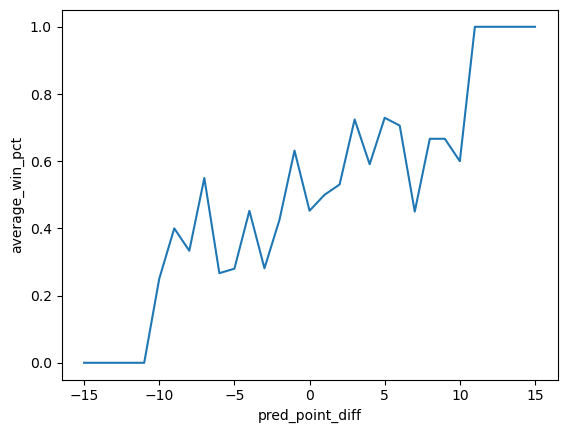

In [120]:
# Plot a graph of average win percentage vs. predicted point differential

df = pd.DataFrame({
    "Season" : mask_ss,
    "pred" : mask_preds,
    "label" : [(t > 0) for t in mask_targets]
})

df["pred_point_diff"] = df["pred"].astype(int)

xdf = df.clip(-30,30).groupby("pred_point_diff")["label"].mean().reset_index(name = "average_win_pct")

seaborn.lineplot(x = xdf["pred_point_diff"], y = xdf["average_win_pct"])

brier: 0.2294338214475995


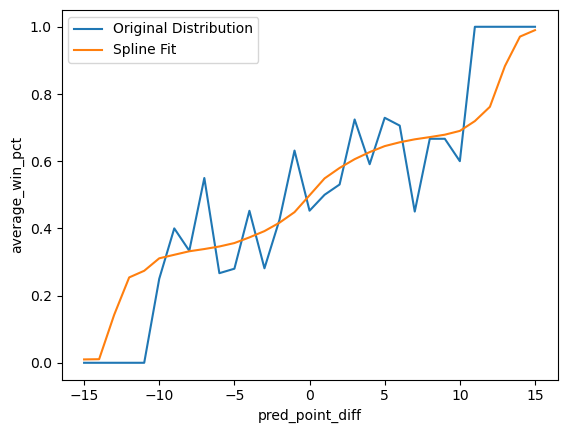

In [121]:
# Fit a Curve to the jagged data derived in the average win percentage vs pred point diff graph

t = 25
dat = list(zip(mask_preds, np.array(mask_targets) > 0))
dat = sorted(dat, key = lambda x:x[0])
pred, label = list(zip(*dat))
spline_model = UnivariateSpline(np.clip(pred, -t, t), label, k = 5)
spline_fit = np.clip(spline_model(np.clip(mask_preds, -t, t)), 0.01, 0.99)
print(f"brier: {brier_score_loss(np.array(mask_targets) > 0, spline_fit)}")
df["spline"] = spline_fit
xdf = df.clip(-30,30).groupby('pred_point_diff')[['spline', 'label']].mean().reset_index()

plt.figure()
plt.xlabel("pred_point_diff")
plt.ylabel('average_win_pct')
plt.plot(xdf['pred_point_diff'], xdf['label'])
plt.plot(xdf['pred_point_diff'], xdf['spline'])
plt.legend(['Original Distribution', 'Spline Fit'])

In [122]:
# For each season's tournament, compute and display the brier score

avg_brier_score = 0.0
num_seasons = 0

for mask_season in set(M_sweet_onwards_data.Season):

    x = df.loc[df["Season"] == mask_season, "spline"].values
    y = df.loc[df["Season"] == mask_season, "label"].values
    print(mask_season, np.round(brier_score_loss(y,x), 5))
    avg_brier_score += brier_score_loss(y,x)
    num_seasons += 1

avg_brier_score /= num_seasons

print("average brier score: ", avg_brier_score)


2003 0.24345
2004 0.25231
2005 0.21817
2006 0.2491
2007 0.18607
2008 0.18268
2009 0.21504
2010 0.22319
2011 0.29944
2012 0.20943
2013 0.22089
2014 0.27207
2015 0.18098
2016 0.23604
2017 0.21512
2018 0.23004
2019 0.23636
2021 0.20446
2022 0.26759
2023 0.27667
2024 0.26007
2025 0.16835
average brier score:  0.22943382144759952
